In [150]:
import pandas as pd
pd.set_option('display.max_rows',None)
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, multilabel_confusion_matrix

In [126]:
df = pd.read_csv("data_final_1.csv", encoding="utf-8", low_memory=False)
df.columns = [col.strip() for col in df.columns]
df = df.drop(columns=["Birthdate", "ID"])

In [127]:
#تبدیل مقادیر چندمین فرزند به عدد
df["Birth Order"].replace("3-3قلو","33", inplace=True)
df["Birth Order"].replace("دوقلو","22", inplace=True)
df["Birth Order"].replace("چهارقلو","44", inplace=True)
df["Birth Order"].replace("nan",np.nan,inplace=True)
df["Birth Order"] = pd.to_numeric(df["Birth Order"], errors='coerce').astype('Int64')
df["Birth Order"].unique()

<IntegerArray>
[1, 3, 5, 2, 4, 44, 33, 6, 7, <NA>]
Length: 10, dtype: Int64

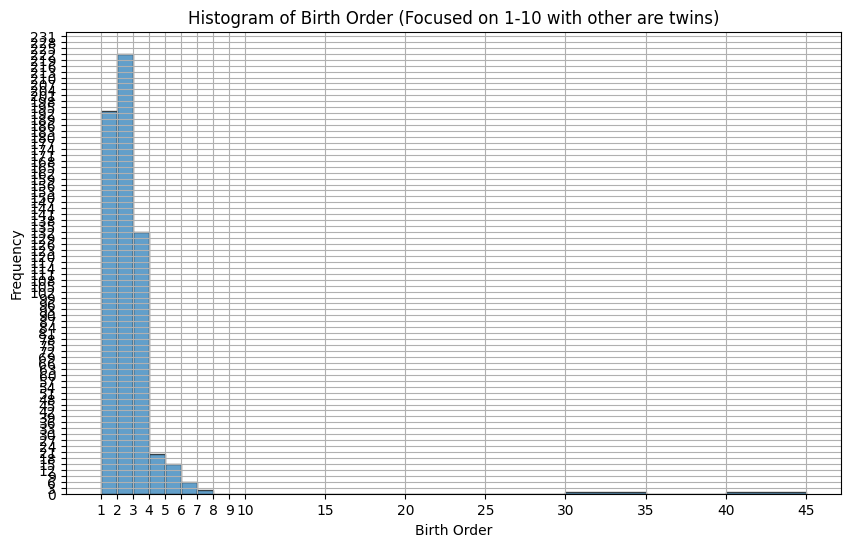

In [128]:
# نمایش هستوگرام چندمین فرزند
bins = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45]


plt.figure(figsize=(10, 6))
df["Birth Order"].hist(bins=bins, edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on 1-10 with other are twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(bins)
max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()

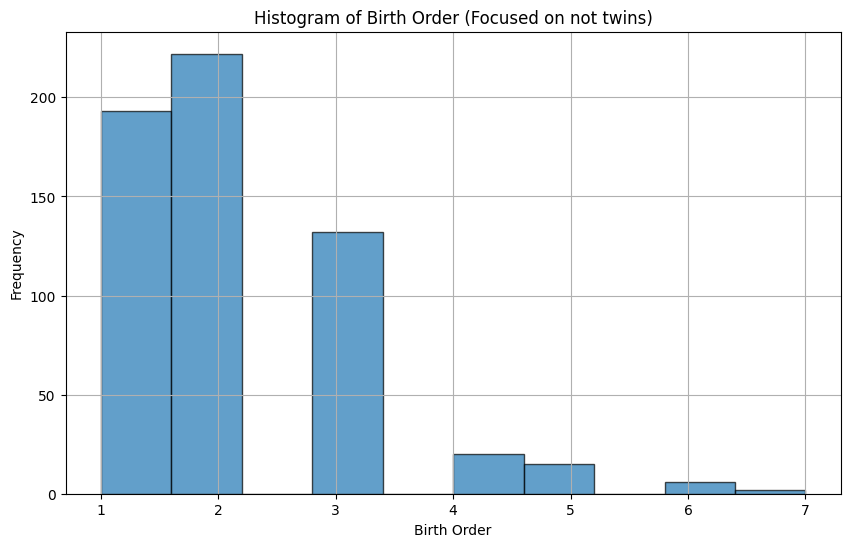

In [129]:
#هستوگرام بدون در نظر گرفتن چند قلو ها
plt.figure(figsize=(10, 6))
df["Birth Order"].where(df["Birth Order"]<10).hist(edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on not twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
# plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()

In [130]:
print(df.isna().sum())

Malnutrition Type                            0
Gender                                       0
Age                                          0
Birth Order                                  6
Mother's Age at Pregncy (Years)              0
Type of Delivery                             0
Mother Underweight (BMI < 18.5)             19
has_hypertension                             0
Blood Pressure (Week 24-30) - Systolic     118
Blood Pressure (Week 24-30) - Diastolic    118
Blood Pressure (Week 31-34) - Systolic     169
Blood Pressure (Week 31-34) - Diastolic    169
Blood Pressure (Week 36-37) - Systolic     224
Blood Pressure (Week 36-37) - Diastolic    224
Abortion History                             3
Gestatiol Diabetes                           3
Diabetes (Week 6-10)                        77
Diabetes (Week 24-30)                      101
Developmental Issues (2 Months)              0
Developmental Issues (9 Months)              1
Developmental Issues (18 Months)             1
Breast Milk S

In [131]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [132]:
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])

In [133]:
df['Birth Order'] = df['Birth Order'].fillna(df['Birth Order'].mode()[0])

In [134]:
df["Abortion History"] = df["Abortion History"].fillna(df["Abortion History"].mode()[0])

In [135]:
df["Type of Delivery"] = df["Type of Delivery"].fillna(df["Type of Delivery"].mode()[0])

In [136]:
df["Mother Underweight (BMI < 18.5)"] = df["Mother Underweight (BMI < 18.5)"].fillna(df["Mother Underweight (BMI < 18.5)"].mode()[0])

In [137]:
df["Blood Pressure (Week 24-30) - Systolic"] = df["Blood Pressure (Week 24-30) - Systolic"].fillna(df["Blood Pressure (Week 24-30) - Systolic"].mode()[0])
df["Blood Pressure (Week 24-30) - Diastolic"] = df["Blood Pressure (Week 24-30) - Diastolic"].fillna(df["Blood Pressure (Week 24-30) - Diastolic"].mode()[0])
df["Blood Pressure (Week 31-34) - Systolic"] = df["Blood Pressure (Week 31-34) - Systolic"].fillna(df["Blood Pressure (Week 31-34) - Systolic"].mode()[0])
df["Blood Pressure (Week 31-34) - Diastolic"] = df["Blood Pressure (Week 31-34) - Diastolic"].fillna(df["Blood Pressure (Week 31-34) - Diastolic"].mode()[0])
df["Blood Pressure (Week 36-37) - Systolic"] = df["Blood Pressure (Week 36-37) - Systolic"].fillna(df["Blood Pressure (Week 36-37) - Systolic"].mode()[0])
df["Blood Pressure (Week 36-37) - Diastolic"] = df["Blood Pressure (Week 36-37) - Diastolic"].fillna(df["Blood Pressure (Week 36-37) - Diastolic"].mode()[0])

In [138]:
df['Gestatiol Diabetes'] = df['Gestatiol Diabetes'].fillna(df['Gestatiol Diabetes'].mode()[0])

In [139]:
df['Diabetes (Week 6-10)'] = df['Diabetes (Week 6-10)'].fillna(df['Diabetes (Week 6-10)'].mode()[0])
df['Diabetes (Week 24-30)'] = df['Diabetes (Week 24-30)'].fillna(df['Diabetes (Week 24-30)'].mean())

In [140]:
df['Developmental Issues (2 Months)'] = df['Developmental Issues (2 Months)'].fillna(df['Developmental Issues (2 Months)'].mode()[0])
df['Developmental Issues (9 Months)'] = df['Developmental Issues (9 Months)'].fillna(df['Developmental Issues (9 Months)'].mode()[0])
df['Developmental Issues (18 Months)'] = df['Developmental Issues (18 Months)'].fillna(df['Developmental Issues (18 Months)'].mode()[0])

In [141]:
df['Breast Milk Sufficiency (3-5 Days)'] = df['Breast Milk Sufficiency (3-5 Days)'].fillna(df['Breast Milk Sufficiency (3-5 Days)'].mode()[0])

In [142]:
df["Head Circumference at Birth (cm)"] = pd.to_numeric(df["Head Circumference at Birth (cm)"], errors='coerce').astype('float64')
df['Head Circumference at Birth (cm)'] = df['Head Circumference at Birth (cm)'].fillna(df['Head Circumference at Birth (cm)'].mean())
df['Head Circumference (14-15 Days)'] = df['Head Circumference (14-15 Days)'].fillna(df['Head Circumference (14-15 Days)'].mean())
df['Head Circumference at 1 Year (cm)'] = df['Head Circumference at 1 Year (cm)'].fillna(df['Head Circumference at 1 Year (cm)'].mean())
df['Head Circumference Check (14-15 Days)'] = df['Head Circumference Check (14-15 Days)'].fillna(df['Head Circumference Check (14-15 Days)'].mean())
df['Head Circumference Check (1 Year)'] = df['Head Circumference Check (1 Year)'].fillna(df['Head Circumference Check (1 Year)'].mean())

In [143]:
df.isna().sum()

Malnutrition Type                          0
Gender                                     0
Age                                        0
Birth Order                                0
Mother's Age at Pregncy (Years)            0
Type of Delivery                           0
Mother Underweight (BMI < 18.5)            0
has_hypertension                           0
Blood Pressure (Week 24-30) - Systolic     0
Blood Pressure (Week 24-30) - Diastolic    0
Blood Pressure (Week 31-34) - Systolic     0
Blood Pressure (Week 31-34) - Diastolic    0
Blood Pressure (Week 36-37) - Systolic     0
Blood Pressure (Week 36-37) - Diastolic    0
Abortion History                           0
Gestatiol Diabetes                         0
Diabetes (Week 6-10)                       0
Diabetes (Week 24-30)                      0
Developmental Issues (2 Months)            0
Developmental Issues (9 Months)            0
Developmental Issues (18 Months)           0
Breast Milk Sufficiency (3-5 Days)         0
Head Circu

In [144]:
df = df.dropna()

In [145]:
df.isna().sum()

Malnutrition Type                          0
Gender                                     0
Age                                        0
Birth Order                                0
Mother's Age at Pregncy (Years)            0
Type of Delivery                           0
Mother Underweight (BMI < 18.5)            0
has_hypertension                           0
Blood Pressure (Week 24-30) - Systolic     0
Blood Pressure (Week 24-30) - Diastolic    0
Blood Pressure (Week 31-34) - Systolic     0
Blood Pressure (Week 31-34) - Diastolic    0
Blood Pressure (Week 36-37) - Systolic     0
Blood Pressure (Week 36-37) - Diastolic    0
Abortion History                           0
Gestatiol Diabetes                         0
Diabetes (Week 6-10)                       0
Diabetes (Week 24-30)                      0
Developmental Issues (2 Months)            0
Developmental Issues (9 Months)            0
Developmental Issues (18 Months)           0
Breast Milk Sufficiency (3-5 Days)         0
Head Circu

In [146]:
y = df["Malnutrition Type"]
X = df.drop(columns=["Malnutrition Type"])

In [147]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [149]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Perform GridSearchCV to find the best parameters
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Update the SVM model with the best parameters
svm_model = grid_search.best_estimator_
svm_model.fit(X_train, y_train)

# Evaluate the model
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00        19
           3       0.00      0.00      0.00         4
           4       0.28      0.83      0.42        18
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00        16
           7       0.77      0.98      0.86        52

    accuracy                           0.55       119
   macro avg       0.15      0.26      0.18       119
weighted avg       0.38      0.55      0.44       119



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00         5
           2       0.07      0.05      0.06        19
           3       0.00      0.00      0.00         4
           4       0.18      0.39      0.25        18
           5       0.00      0.00      0.00         5
           6       0.09      0.06      0.07        16
           7       0.83      0.75      0.79        52

    accuracy                           0.40       119
   macro avg       0.17      0.18      0.17       119
weighted avg       0.41      0.40      0.40       119



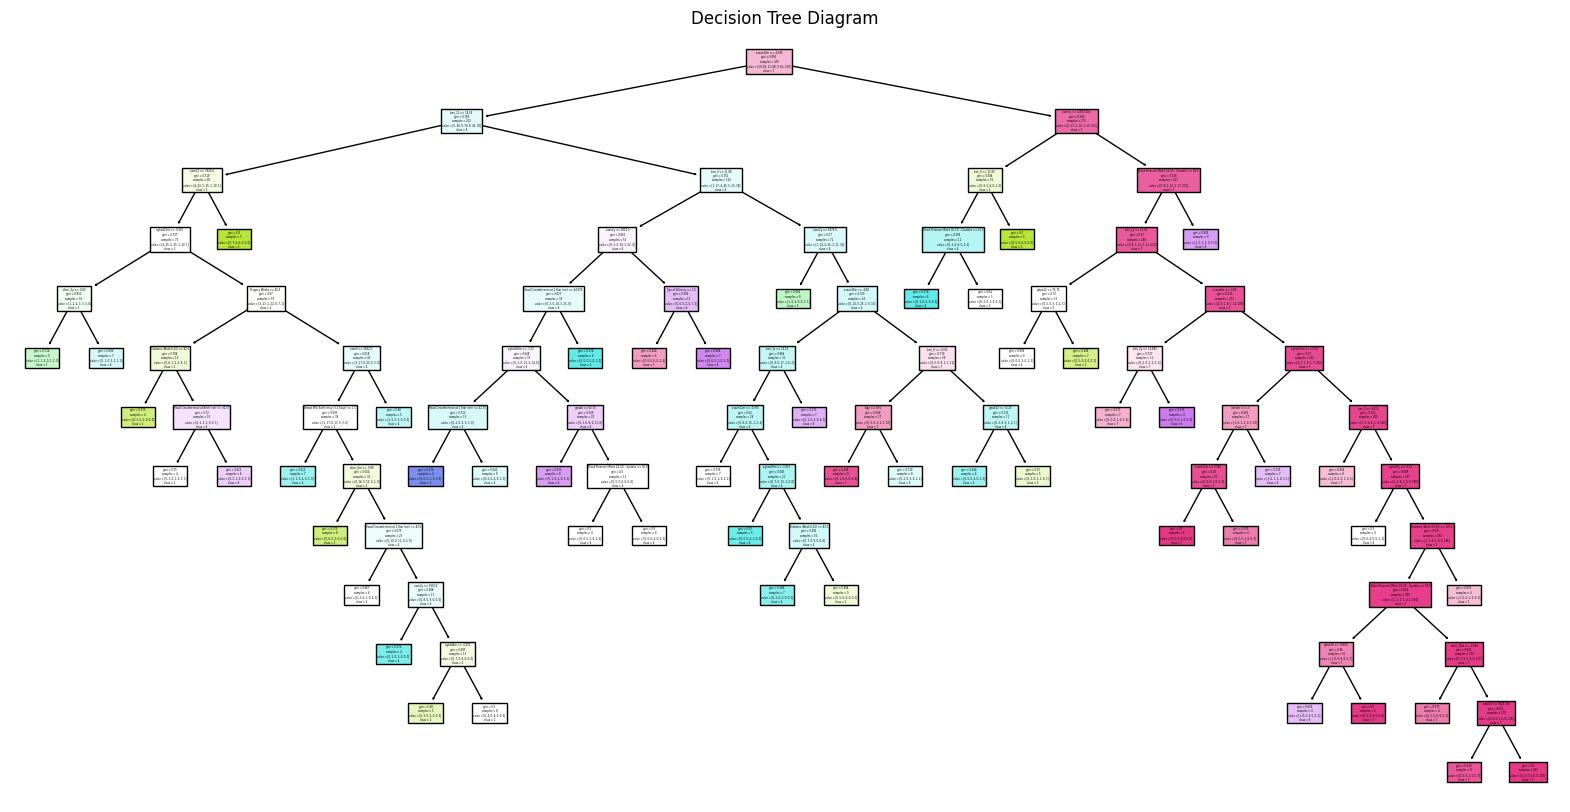

In [153]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import GridSearchCV

# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV to find the best parameters
grid_search_dt = GridSearchCV(dt_model, param_grid, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

# Update the Decision Tree model with the best parameters
dt_model = grid_search_dt.best_estimator_
dt_model.fit(X_train, y_train)

# Evaluate the model
y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))

# Plot the Decision Tree diagram
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=[str(cls) for cls in y.unique()], filled=True)
plt.title("Decision Tree Diagram")
plt.show()

In [154]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Perform GridSearchCV to find the best parameters
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

# Update the Random Forest model with the best parameters
rf_model = grid_search_rf.best_estimator_
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         5
           2       0.18      0.16      0.17        19
           3       0.00      0.00      0.00         4
           4       0.12      0.17      0.14        18
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00        16
           7       0.83      0.94      0.88        52

    accuracy                           0.46       119
   macro avg       0.16      0.18      0.17       119
weighted avg       0.41      0.46      0.43       119



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Define the SVR model
svr_model = SVR()

# Define the parameter grid for GridSearchCV
param_grid_svr = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # Only relevant for 'poly' kernel
}

# Perform GridSearchCV to find the best parameters
grid_search_svr = GridSearchCV(svr_model, param_grid_svr, cv=5, scoring='neg_mean_squared_error')
grid_search_svr.fit(X_train, y_train)

# Update the SVR model with the best parameters
best_svr_model = grid_search_svr.best_estimator_
best_svr_model.fit(X_train, y_train)

# Evaluate the model
y_pred_svr = best_svr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_svr)
print(f"Mean Squared Error: {mse}")

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Define the parameter grid for GridSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Perform GridSearchCV to find the best parameters
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train, y_train)

# Update the XGBoost model with the best parameters
best_xgb_model = grid_search_xgb.best_estimator_
best_xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred_xgb = best_xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the KNN model
knn_model = KNeighborsClassifier()

# Define the parameter grid for GridSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Perform GridSearchCV to find the best parameters
grid_search_knn = GridSearchCV(knn_model, param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Update the KNN model with the best parameters
best_knn_model = grid_search_knn.best_estimator_
best_knn_model.fit(X_train, y_train)

# Evaluate the model
y_pred_knn = best_knn_model.predict(X_test)
print(classification_report(y_test, y_pred_knn))